In [34]:
import pandas as pd

dataset = pd.read_csv("high_popularity_spotify_data.csv")

cols_of_interest = ['energy','tempo','danceability','playlist_genre','loudness','liveness','valence','track_artist','time_signature','speechiness','track_popularity','track_album_name','playlist_name','track_name','track_album_release_date','instrumentalness','mode','key','duration_ms','acousticness','playlist_subgenre']

dataset_cleaned = dataset[cols_of_interest].copy()

dataset_cleaned['artist_list'] = dataset_cleaned['track_artist'].str.split(",")

dataset_exploded = dataset_cleaned.explode('artist_list')

dataset_exploded['artist_list'] = dataset_exploded['artist_list'].str.strip()

dataset_exploded['song_count'] = dataset_exploded.groupby('artist_list')['artist_list'].transform('size')

# 1. Manually fix the specific split-name error
# We use a dictionary to map the "bad" names to the "correct" one
name_fixes = {
    'Tyler': 'Tyler, the Creator',
    'The Creator': 'Tyler, the Creator'
}

# 2. Apply the fix to your exploded column
dataset_exploded['artist_list'] = dataset_exploded['artist_list'].replace(name_fixes)

# 3. Optional: Remove any extra whitespace that might have caused issues
dataset_exploded['artist_list'] = dataset_exploded['artist_list'].str.strip()

# 1. Define the specific "broken" names you want to delete
bad_names = ['Tyler', 'the Creator']

# 2. Keep only the rows where the artist is NOT in that list
dataset_exploded = dataset_exploded[~dataset_exploded['artist_list'].isin(bad_names)]



dataset_final = dataset_exploded[dataset_exploded['song_count'] >= 10].copy() # Only using artists with more than 10 songs on the list

# 4. Check your results
print(f"Remaining rows: {len(dataset_final)}")
print(f"Unique artists left: {dataset_final['artist_list'].nunique()}")

# 1. Get the counts for each artist
artist_counts = dataset_final['artist_list'].value_counts()

# 2. Display the Top 10 artists by song count
print("--- Top 10 Artists in our Dataset ---")
print(artist_counts.head(10))

# 3. Display the bottom 5 (the ones closest to your '10 song' cutoff)
print("\n--- Artists at the Cutoff ---")
print(artist_counts.tail(5))

# 4. Quick Stats for your Prof
print(f"\nTotal Songs: {len(dataset_final)}")
print(f"Average songs per artist: {artist_counts.mean():.2f}")





Remaining rows: 492
Unique artists left: 32
--- Top 10 Artists in our Dataset ---
artist_list
Bad Bunny             60
Lil Baby              26
Future                22
Tyler, the Creator    20
Travis Scott          20
Metro Boomin          19
Drake                 19
Rauw Alejandro        15
21 Savage             15
Bruno Mars            14
Name: count, dtype: int64

--- Artists at the Cutoff ---
artist_list
USHER                    11
Sabrina Carpenter        11
Red Hot Chili Peppers    10
Lil Uzi Vert             10
Pitbull                  10
Name: count, dtype: int64

Total Songs: 492
Average songs per artist: 15.38


In [35]:
# 1. Set your seed for reproducibility (so your results don't change every time you run it)
import numpy as np
np.random.seed(42)

# 2. Use a lambda function to grab the top 25 (or fewer) rows for each artist
df_balanced = dataset_final.groupby('artist_list').apply(
    lambda x: x.sample(n=min(len(x), 25))
).reset_index(drop=True)

# 3. Final Verification for your Prof
print(f"New total songs: {len(df_balanced)}")
print(f"Max songs for any artist: {df_balanced['artist_list'].value_counts().max()}")
print(f"Bad Bunny's new count: {len(df_balanced[df_balanced['artist_list'] == 'Bad Bunny'])}")



New total songs: 456
Max songs for any artist: 25
Bad Bunny's new count: 25


C:\Users\baker\AppData\Local\Temp\ipykernel_17600\2042530907.py:6: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_balanced = dataset_final.groupby('artist_list').apply(


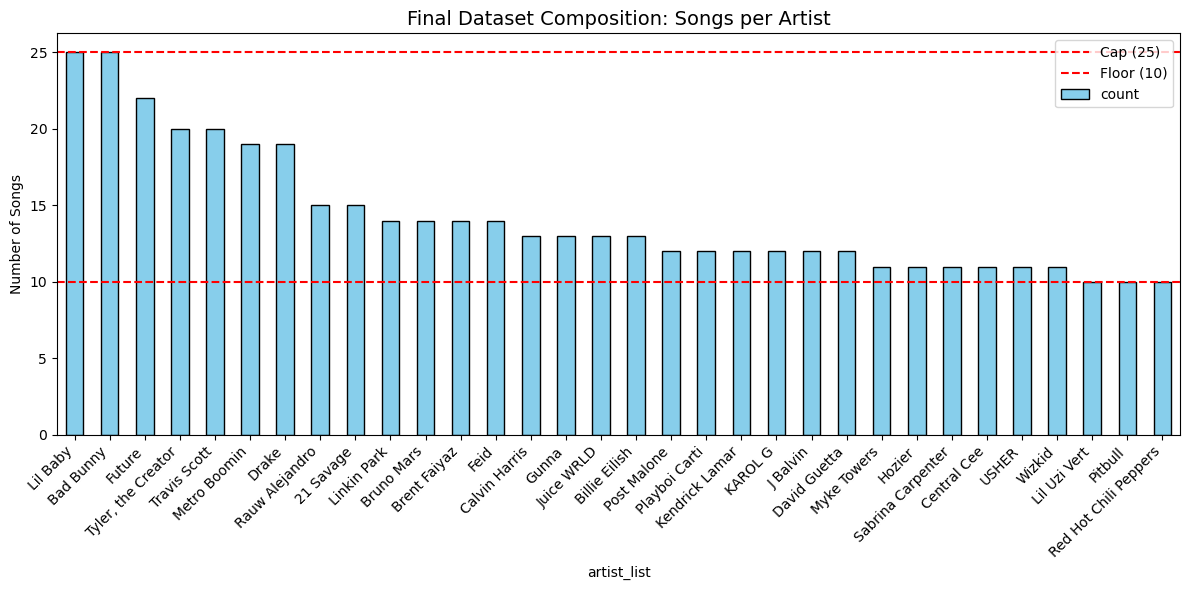

In [36]:
import matplotlib.pyplot as plt
import numpy as np

# --- 1. Bar Chart: Run this after your filtering/balancing logic ---
plt.figure(figsize=(12, 6))
# Replace 'df_balanced' with your final dataframe name
counts = df_balanced['artist_list'].value_counts()
counts.plot(kind='bar', color='skyblue', edgecolor='black')

plt.axhline(y=25, color='red', linestyle='--', label='Cap (25)')
plt.axhline(y=10, color='red', linestyle='--', label='Floor (10)')

plt.title('Final Dataset Composition: Songs per Artist', fontsize=14)
plt.ylabel('Number of Songs')
plt.xticks(rotation=45, ha='right')
plt.legend()
plt.tight_layout()
plt.show()



In [41]:
dataset_final.columns

cols_final = ['energy','tempo','danceability','playlist_genre','loudness','liveness','valence','speechiness','instrumentalness','acousticness','playlist_subgenre','artist_list']

dataset_final = dataset_final[cols_final]

dataset_final

,energy,tempo,danceability,playlist_genre,loudness,liveness,valence,speechiness,instrumentalness,acousticness,playlist_subgenre,artist_list
0,0.592,157.969,0.521,pop,-7.777,0.1220,0.535,0.0304,0.000000,0.3080,mainstream,Bruno Mars
1,0.507,104.978,0.747,pop,-10.171,0.1170,0.438,0.0358,0.060800,0.2000,mainstream,Billie Eilish
3,0.910,112.966,0.670,pop,-4.070,0.3040,0.786,0.0634,0.000000,0.0939,mainstream,Sabrina Carpenter
4,0.783,149.027,0.777,pop,-4.477,0.3550,0.939,0.2600,0.000000,0.0283,mainstream,Bruno Mars
7,0.247,148.101,0.467,pop,-12.002,0.1700,0.126,0.0431,0.000271,0.6120,mainstream,Billie Eilish
...,...,...,...,...,...,...,...,...,...,...,...,...
1627,0.413,146.050,0.747,hip-hop,-11.197,0.1700,0.481,0.4880,0.000000,0.8480,drill,Central Cee
1629,0.674,140.065,0.922,hip-hop,-4.429,0.1280,0.726,0.3660,0.000003,0.3230,drill,Central Cee
1678,0.485,100.053,0.843,latin,-8.735,0.1070,0.689,0.1950,0.067500,0.1810,afro-latin,Drake
1684,0.642,83.389,0.463,latin,-4.474,0.0686,0.339,0.3400,0.000000,0.3140,afro-latin,Future


In [43]:
# 1. Numerical Profiles (Mean and Std)
# This gives you both the 'vibe' and the 'consistency'
num_features = ['energy', 'danceability', 'valence', 'tempo']
artist_stats = dataset_final.groupby('artist_list')[num_features].agg(['mean', 'std'])

# 2. Categorical DNA (Genre Distribution)
# This creates a table where each column is a genre and the value is the % of songs
genre_dna = pd.crosstab(dataset_final['artist_list'], dataset_final['playlist_genre'], normalize='index')

# 3. Combine them into one "Master Profile"
artist_master_profiles = pd.concat([artist_stats, genre_dna], axis=1)

# Display a sample for Tyler, the Creator
print(artist_master_profiles.loc['Tyler, the Creator'])
print(artist_master_profiles.loc['Sabrina Carpenter'])


(energy, mean)           0.731700
(energy, std)            0.130371
(danceability, mean)     0.532000
(danceability, std)      0.113891
(valence, mean)          0.579000
(valence, std)           0.179350
(tempo, mean)           94.569400
(tempo, std)            22.522523
afrobeats                0.000000
ambient                  0.000000
arabic                   0.000000
blues                    0.000000
electronic               0.000000
folk                     0.000000
gaming                   0.000000
hip-hop                  0.600000
latin                    0.000000
pop                      0.400000
r&b                      0.000000
rock                     0.000000
world                    0.000000
Name: Tyler, the Creator, dtype: float64
(energy, mean)            0.729091
(energy, std)             0.114441
(danceability, mean)      0.688182
(danceability, std)       0.031937
(valence, mean)           0.674727
(valence, std)            0.064652
(tempo, mean)           111.224909
